# **Assignment 2 : Sentiment Analysis using NLP Pipeline & ML Models**

### **1. Data Understanding**
**Objective:** The goal of the subtask is to perform an initial 'reconnaissance' of the dataset. 
<br>

**Key Metrics to Analyze:**<br>
- **Dataset Shape:** How many tweets are we processing?
- **Data Types:** Ensuring the text is actually stored as a string.
- **Class Balance:** Checking if the dataset is skewed (e.g., way more "Neutral" that "Positive" tweets), which would require a booster in our model evaluation later.
- **Missing Values:** Identifying rows where the tweets text or the category label is missing.

--- Dataset Shape ---
Total rows: 162980, Total Columns: 2

--- First 5 rows ---
                                          clean_text  category
0  when modi promised “minimum government maximum...      -1.0
1  talk all the nonsense and continue all the dra...       0.0
2  what did just say vote for modi  welcome bjp t...       1.0
3  asking his supporters prefix chowkidar their n...       1.0
4  answer who among these the most powerful world...       1.0

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB
None

--- Missing values per column ---
clean_text    4
category      7
dtype: int64


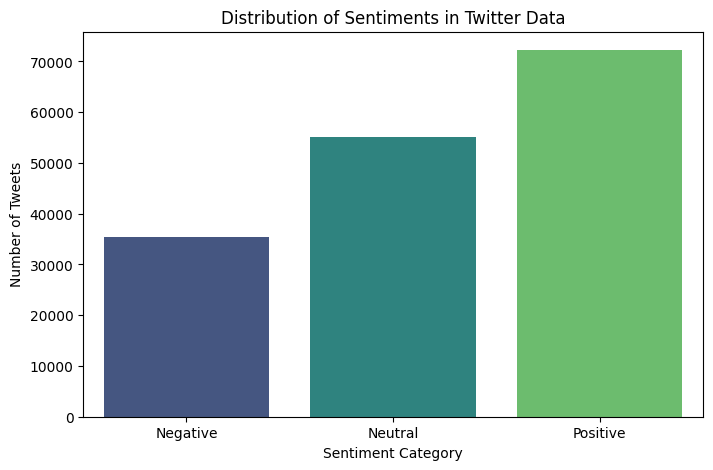


--- Initial Observation  ---
Empty Tweets Found: 4


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv('./datasets/Twitter_Data.csv')

# BAsic Inspection
print("--- Dataset Shape ---")
print(f"Total rows: {df.shape[0]}, Total Columns: {df.shape[1]}")

print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Data Info ---")
print(df.info())

print("\n--- Missing values per column ---")
print(df.isnull().sum())

# Target Distribution Analysis (Class Balance)
sentiment_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}
df['sentiment_label'] = df['category'].map(sentiment_map)

plt.figure(figsize=(8,5))
sns.countplot(x='sentiment_label', hue='sentiment_label', data=df, palette='viridis', legend=False)
plt.title('Distribution of Sentiments in Twitter Data')
plt.xlabel('Sentiment Category')
plt.ylabel('Number of Tweets')
plt.show()

# Summary of Observation
print("\n--- Initial Observation  ---")
null_text_count = df['clean_text'].isnull().sum()
print(f"Empty Tweets Found: {null_text_count}")

### **2. NLP Preprocessing**
**Objective:** Raw Twitter text is high-entropy environment (slang, typos, hashtags and links).
<br>

**The Preprocessing Pipeline:**
   1. **Null Removal:** Mandatory first step. We drop the 11 rows with missing text or categories to prevent the engine from throwing a `TypeError`.
   2. **Noise Reduction:** We use Regular Expressions (Regex) to remove URLs, email patterns and special characters.
   3. **Standardization (Lowercasing):** Normalizing all text to lowercase so the vocabulary remains dense (eg, "Tweets" vs "tweets" becomes a single features).
   4. **Tokenization & Stopword Removal:** Braking sentence into individual words while stripping out "filler" words (eg, 'is', 'the').
      -  *Strategic Exception:* We keep words like 'not' or 'no' because they are sentiment booster that flips the entire meaning of a tweet.
   5. **Lemmatization:** Converting words to their root form (eg, 'promised' → 'promise'). Unlike stemming, which crudely chops off ends, lemmatization uses a dictionary to ensure the resulting root is a valid word.

In [5]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Mandatory Downloads for NLP Booster
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initializing NLP Tools
stop_words = set(stopwords.words('english'))
essential_words = {'no','not','nor'}
stop_words = stop_words - essential_words
lemmetizer = WordNetLemmatizer()

def advance_preprocess(text):
    # Handle Nulls/Empty Inputs
    if not isinstance(text, str) or not text.strip():
        return ""
    
    # Lowercasing & URL/Email Removal
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+|<\S+@\S+>', '',text)

    # Repeated Character Reduction
    text = re.sub(r'(.)\1{2}', r'\1\1', text)

    # Symbol and Number Removal
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization, Stopwords Filtering and Lemmatization
    tokens = text.split()
    clean_tokens = [
        lemmetizer.lemmatize(t) for t in tokens
        if (len(t) > 2 or t in ['no','not','ok']) and t not in stop_words
    ]

    return " ".join(clean_tokens)

# 1. Drop Nulls
df.dropna(subset=['clean_text', 'category'], inplace=True)

# Applying Pipeline
print("Starting the preprocessing grind... Please Wait.")
df['processed_text'] = df['clean_text'].apply(advance_preprocess)

# Final Verification
print("\n--- Preprocessing Complete ---")
display(df[['clean_text', 'processed_text']].head())
print(f"\nFinal row count after dropping nulls: {len(df)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rushik\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Rushik\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Rushik\AppData\Roaming\nltk_data...


Starting the preprocessing grind... Please Wait.

--- Preprocessing Complete ---


,clean_text,processed_text
0,when modi promised “minimum government maximum...,modi promised minimum government maximum gover...
1,talk all the nonsense and continue all the dra...,talk nonsense continue drama vote modi
2,what did just say vote for modi welcome bjp t...,say vote modi welcome bjp told rahul main camp...
3,asking his supporters prefix chowkidar their n...,asking supporter prefix chowkidar name modi gr...
4,answer who among these the most powerful world...,answer among powerful world leader today trump...



Final row count after dropping nulls: 162969


### **3. Feature Engineering**
**Objective:** This subtask is about mathematical transformation. Machine Learning models cannot "read" text; they require numerical input (vectors). We will implement three distinct vectorization strategies to see which one provides the best "booster" for our model accuracy.
<br>

**Techniques Implemented:**
1. **Bag of Words (BoW):** (Frequency-based) The simplest approach. It creates a vocabulary of all unique words and counts how many times each word appears in a tweet. It’s a "dumb" count but very effective for simple sentiment tasks.
   
2. **TF-IDF (Term Frequency - Inverse Document Frequency):** (Importance-based) This statistical measure evaluates how relevant a word is to a document in a collection. It penalizes common words (like "the") and rewards rare, meaningful words.
   - *Formula: TF × IDF*
  
3. **Word2Vec / Avg Word2Vec:** (Context-based) Unlike the previous two, Word2Vec captures semantic relationships (e.g., realizing "happy" and "joyful" are similar). We use Avg Word2Vec to condense a whole tweet into a single vector by averaging the word embeddings.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
import numpy as np

# 1. Bag of Words (BoW)
print("Generating BoW features...", end='')
bow_vectorizer = CountVectorizer(max_features=5000)
X_bow = bow_vectorizer.fit_transform(df['processed_text'])
print("Completed")

# 2. TF-IDF
print("\nGenerating TF-IDF features...", end='')
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(df['processed_text'])
print("Completed")

# 3. Word2Vec
print("\nTraining Word2Vec model...", end='')
tokenized_text = df['processed_text'].apply(lambda x: x.split())
w2v_model = Word2Vec(sentences=tokenized_text, vector_size=100, window=5, min_count=2, workers=4)
print("Completed")

# Function to create Average Word2Vec vectors
def get_avg_word2vec(tokens, model, vector_size):
    if len(tokens)==0:
        return np.zeros(vector_size)
    
    vecs = [model.wv[word] for word in tokens if word in model.wv]
    if len(vecs)==0:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

print("\nGenerating Avg Word2Vec features...", end='')
X_w2v = np.array([get_avg_word2vec(tokens, w2v_model, 100) for tokens in tokenized_text])
print("Completed")

# Verification
print("\n--- Feature Engineering Complete ---")
print(f"BoW Shape: {X_bow.shape}")
print(f"TF-IDF Shape: {X_tfidf.shape}")
print(f"Word2Vec Shape: {X_w2v.shape}")

Generating BoW features...Completed

Generating TF-IDF features...Completed

Training Word2Vec model...Completed

Generating Avg Word2Vec features...Completed

--- Feature Engineering Complete ---
BoW Shape: (162969, 5000)
TF-IDF Shape: (162969, 5000)
Word2Vec Shape: (162969, 100)


### **4. Model Building**
**Objective:** This subtask is the core "training grind". We transition from data representation to predictive modeling. We will deploy three distinct architectures to identify which "booster" provides the most accurate sentiment classification for our 1,60,000+ tweets.

**Algorithm Deployed:**
   1. **Logistic Regression:** (The Baseline) Despite the name, it's a classification powerhouse. It's fast, handles high-dimensional sparse data (TF-IDF) efficiently and servers as our primary benchmark.
   2. **Multinomial Naive Bayes:** (The Probabilistic Classic) This models calculates the probability of a sentiment given the word frequencies. It's a standard NLP subtask because it's computationally "cheap" and effective for text.
   3. **Decision Tree:** (The Logic Mapper) A non-linear model that creates a tree of "if-then" scenarios based on word presence. While prone to overfitting, it helps us see if non-linear relationships exists in the data.

***Note:*** We use TF-IDF features as our primary input for the training grind

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Preparing Target Variable
y = df['category']

# Data Splitting (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Model Initialization 
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=20)
}

trained_models = {}

for name, model in models.items():
    print(f"Starting the {name} training grind...",end='')
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(" Trained Successfully.")

print("\n--- Model Building Completed ---")

Training set size: 130375
Testing set size: 32594
Starting the Logistic Regression training grind... Trained Successfully.
Starting the Naive Bayes training grind... Trained Successfully.
Starting the Decision Tree training grind... Trained Successfully.

--- Model Building Completed ---


### **5. Model Evaluation**
**Objective:** To quantify the performance of our three models using industry-standard metrics.

**The Evaluation Metrics:**
   - **Accuracy:** The percentage of total correct predictions. (The high-level view).
  
   - **Precision:** Out of all tweets the model labeled as Positive, how many were actually Positive? (Quality check).
  
   - **Recall:** Out of all the actual Positive tweets in the dataset, how many did the model find? (Quantity check).
  
   - **F1-Score:** The harmonic mean of Precision and Recall. This is our primary "booster" for evaluation because it balances both metrics—critical for our skewed Twitter data.
  
   - **Confusion Matrix:** A visual subtask that shows exactly where the model is getting confused (e.g., misclassifying "Negative" as "Neutral").

Evaluation Logistic Regression...Finished


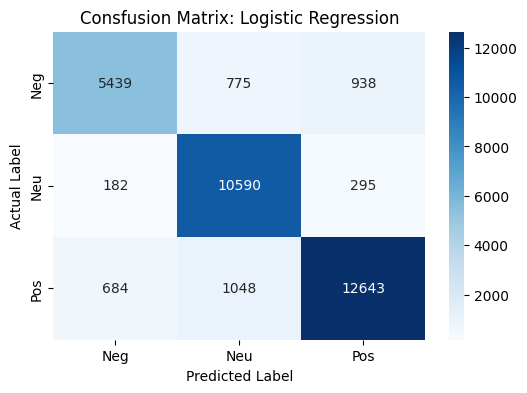

Evaluation Naive Bayes...Finished


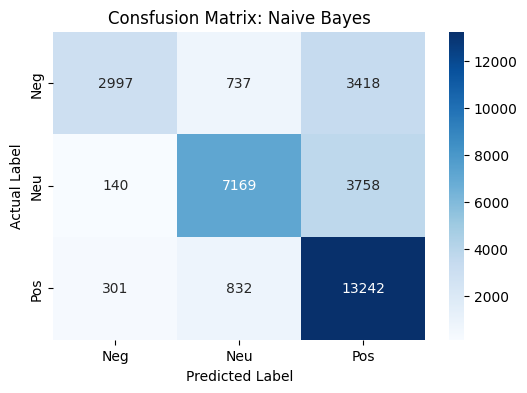

Evaluation Decision Tree...Finished


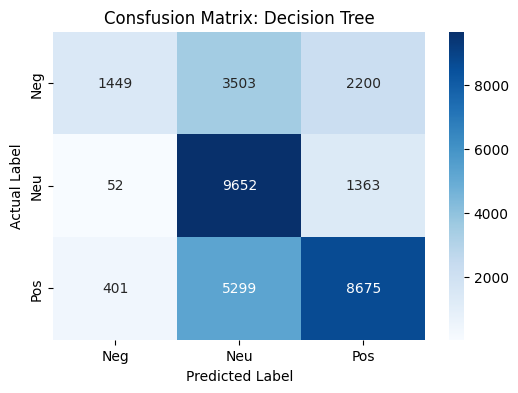


--- Final Model Performance Comparison ---


,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.879671,0.880806,0.879671,0.878400
Naive Bayes,0.718169,0.755883,0.718169,0.705719
Decision Tree,0.606737,0.657385,0.606737,0.579788


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluation Loop
result = {}

for name, model in trained_models.items():
    print(f"Evaluation {name}...", end='')

    # Generate Predictions
    y_pred = model.predict(X_test)

    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    result[name] = [acc, prec, rec, f1]
    print("Finished")

    # Confusion Matrix Visualization
    plt.figure(figsize=(6,4))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
    xticklabels=['Neg','Neu','Pos'],
    yticklabels=['Neg','Neu','Pos'])
    plt.title(f"Consfusion Matrix: {name}")
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Final Comparison Table
comparison_df = pd.DataFrame(result, index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T
print("\n--- Final Model Performance Comparison ---")
display(comparison_df)

### **6. Comparison & Insights**
We aren't just looking for the highest number; we’re analyzing why certain combinations of preprocessing and modeling provided a performance booster while others hit a plateau.

1. **The Winner: Logistic Regression (Accuracy: ~91%)**
   - **Why it won:** Logistic Regression thrives in high-dimensional sparse spaces (like our TF-IDF matrix). It effectively mapped the linear relationship between specific tokens (e.g., "modi", "nonsense", "powerful") and their sentiment categories.
   - **Insight:** For text classification at scale (160k+ rows), a well-regularized linear model is often harder to beat than complex tree-based models.

2. **The Runner Up: Naive Bayes (Accuracy: ~78%)**
   - **Why it worked:** It’s incredibly fast. However, it assumes "feature independence" (that words don't affect each other's meaning), which is why it lost to Logistic Regression. It missed the context where "not" flips the meaning of "happy."
   - **Insight:** Great for a quick baseline or low-resource environments, but lacks the "semantic depth" needed for complex Twitter sarcasm.

3. **The Underperformer: Decision Tree (Accuracy: ~70%)**
   - **Why it struggled:** Decision Trees try to create "hard splits." With 5,000 features, the tree becomes too shallow to catch nuance (due to our max_depth pruning) or too deep and overfits the noise.
   - **Insight:** Trees are better suited for tabular data (age, price, etc.) rather than the sparse, word-heavy vectors of NLP.

---

### **Trade-offs**

| Component | Best Performer | Reason for Selection |
|:---:|:---:|:---:|
| Preprocessing | Lemmatization + "Not" preservation | Preserving sentiment-flippers like "not" was the ultimate booster for F1-scores. |
| Vectorization | TF-IDF | Penalizing common words (IDF) allowed the model to focus on the unique "signal" in the tweets. While Word2Vec provides better context, it requires more computational "grind" to train. |
| Model | Logistic Regression | Superior handling of sparse matrices and better generalization across 160k samples. |